In [1]:
import periapsis as p
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt

# ID 12560

    Type    ACS       RAdeg      DEdeg  Nobs
989    m  12560  154.404545 -46.415366    35


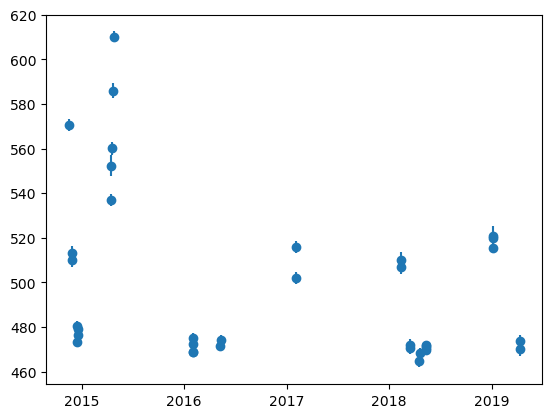

In [2]:
ID = 12560
M_vis = 0.81

list = Table.read("data/ngc3201/J_A+A_632_A3/list.dat", format="ascii.no_header").to_pandas()
colnames=["Type", "ACS", "RAdeg", "DEdeg", "Nobs"]
# Add column names to the DataFrame
list.columns = colnames
catalog = list[list['ACS'] == ID]

data = Table.read("data/ngc3201/J_A+A_632_A3/tablea1m.dat", format="ascii.no_header").to_pandas()
colnames=["ACS", "RAdeg", "DEdeg", "F606Wmag", "Date", "BRV", "e_BRV", "Pvar"]
data.columns = colnames
epochs = data[data['ACS'] == ID]

print(catalog)

date = np.array(2000.0 + (epochs['Date'] - 2451545.0)/365.25)
plt.errorbar(date, epochs['BRV'], yerr=epochs['e_BRV'], fmt='o')
plt.show()

In [3]:
import astropy.units as u
conv = (u.km/u.s).to(u.au/u.yr)

priors = {
    'Tepoch': p.FixedPrior(2017.0),
    'M1': p.FixedPrior(M_vis),
    'M0': p.UniformPrior(-np.pi, np.pi),
    'K1': p.UniformPrior(10.0*conv, 100.0*conv),
    'P': p.LogUniformPrior(1e-4, 1e0),
    'e': p.UniformPrior(0.0, 0.9),
    'omega1': p.UniformPrior(0.0, 2*np.pi),
    'systemic_velocity': p.UniformPrior(300 * conv, 700 * conv),
}
rv_data = p.RadialVelocityData(
    t = date,
    rv = np.array(epochs['BRV'])*conv,
    rv_err = np.array(epochs['e_BRV'])*conv,
    system=1,
)
fitter = p.MCMCFitter(
    nwalkers=32,
    niter=10000,
    sample_params=['M0', 'K1', 'e', 'P', 'omega1', 'systemic_velocity'],
    **priors
)
results = fitter.fit(rv_data, np.random.default_rng(3201))

100%|██████████| 10000/10000 [00:08<00:00, 1204.29it/s]


/Users/mw/Research/software/periapsis/src/periapsis/plotting/plots.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


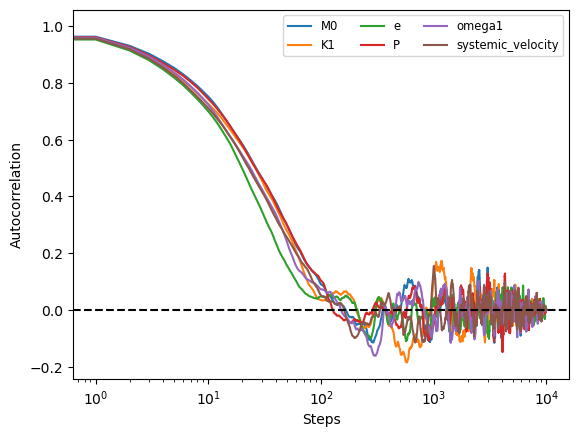

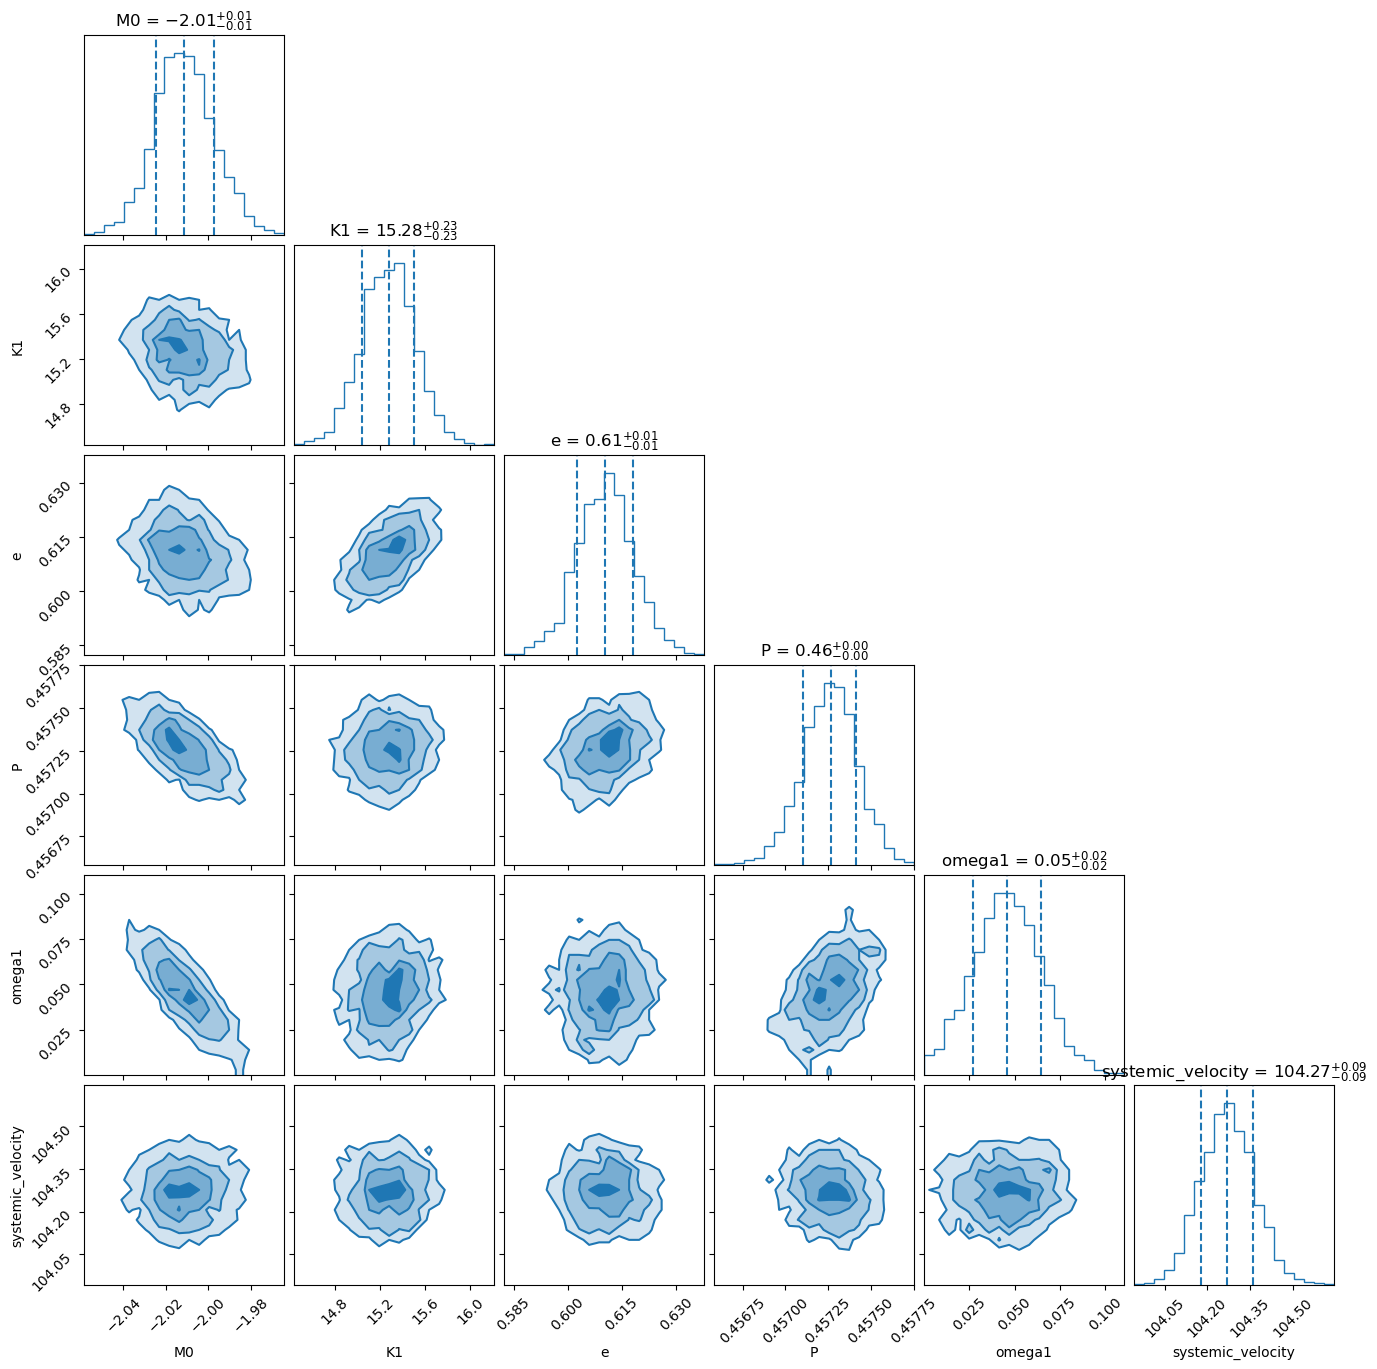

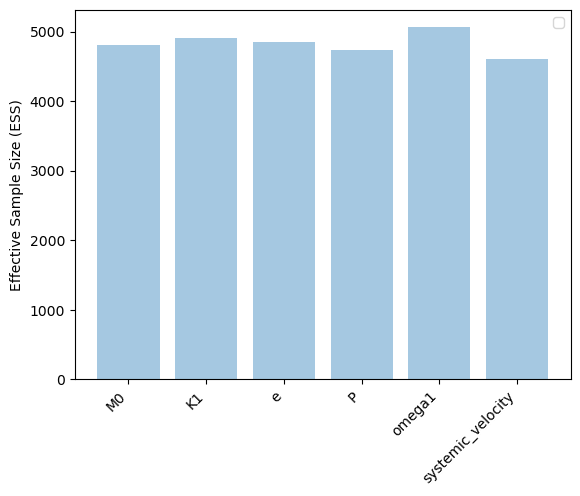

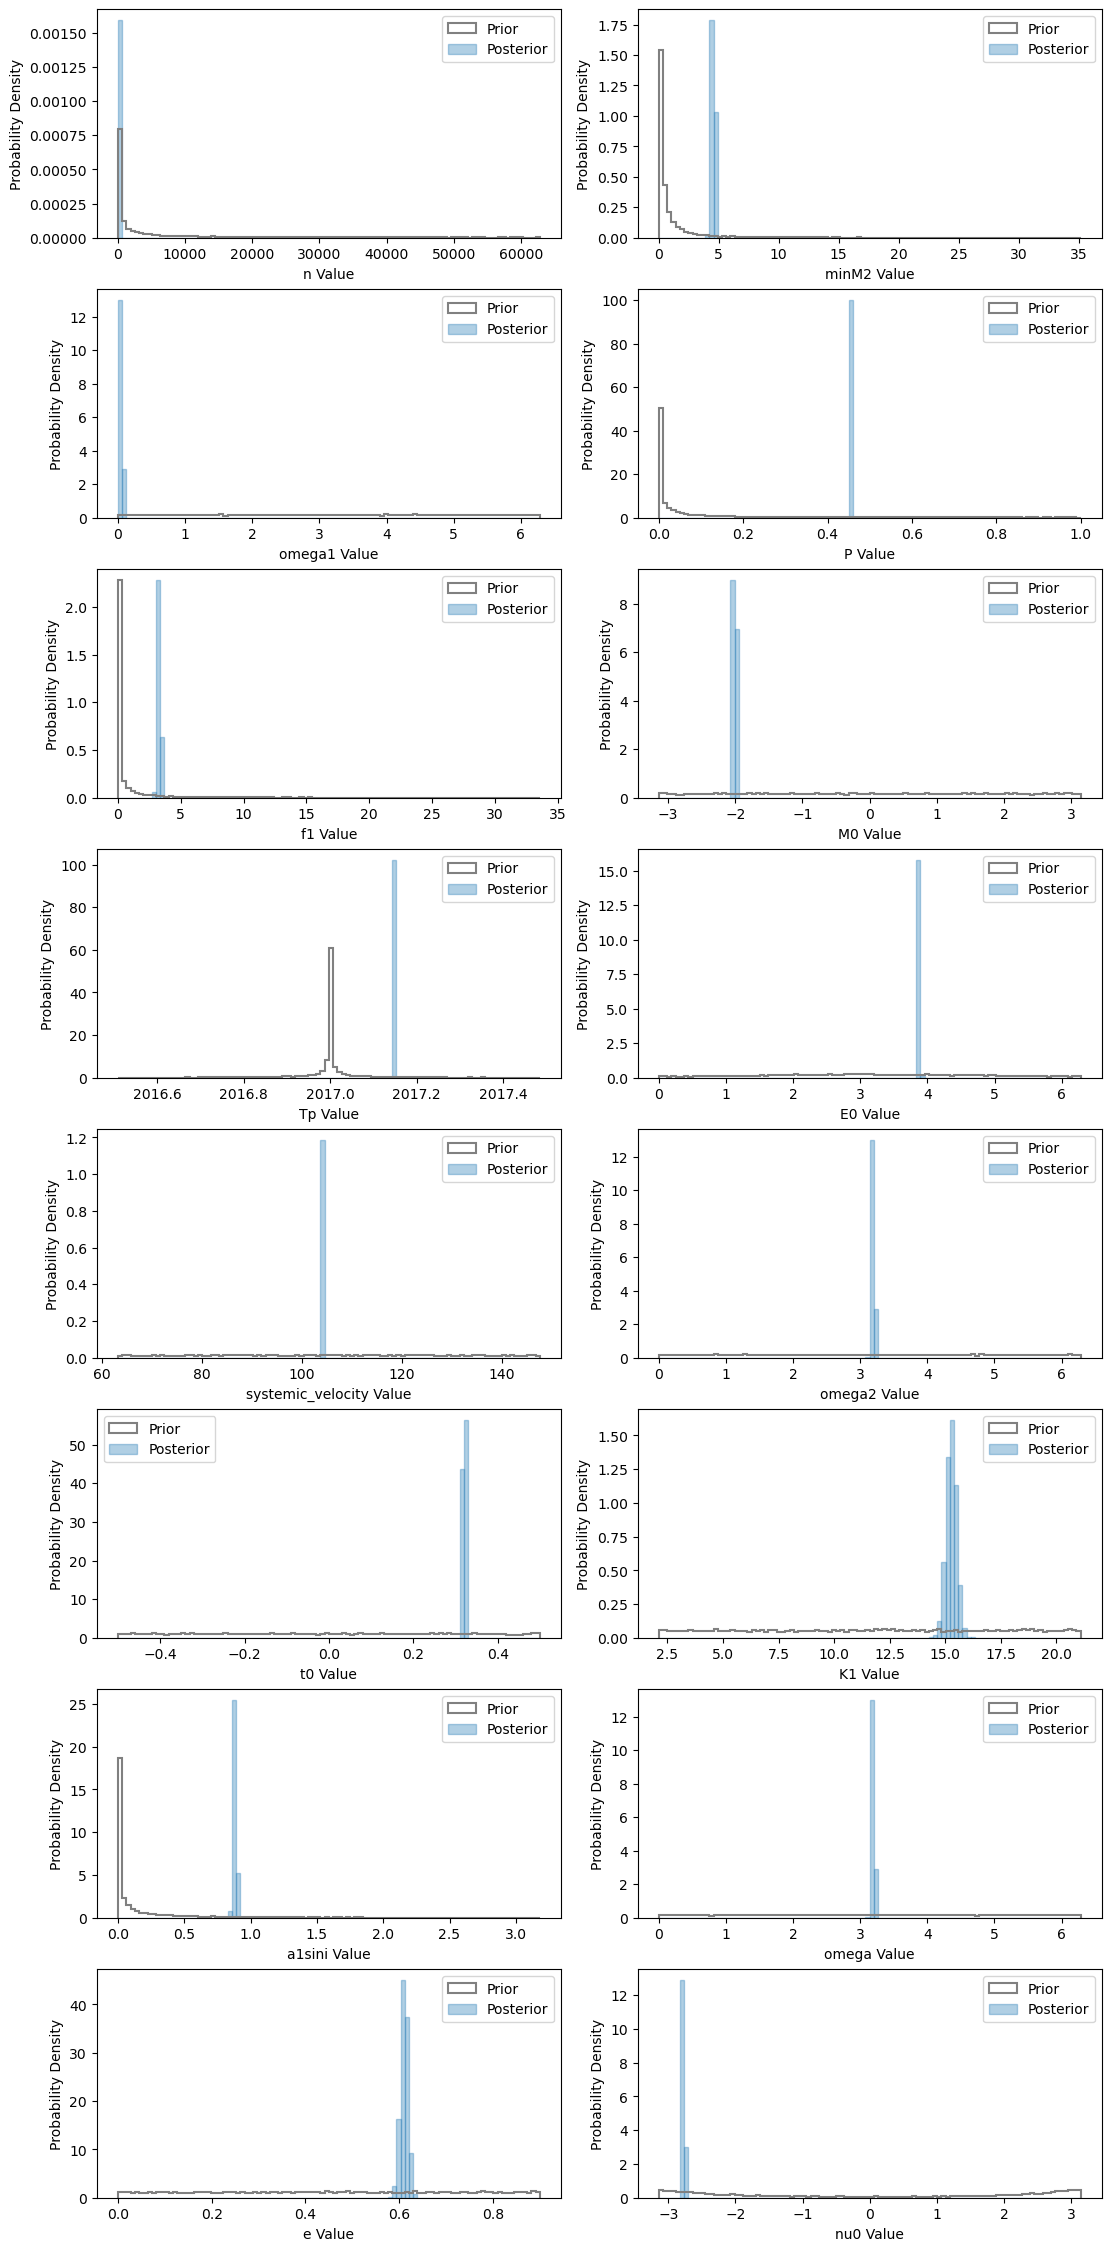

In [4]:
p.mcmc_autocorrelation_plot(results);
p.corner_plot(results);
p.ess_distribution_plot(results);
p.posterior_over_prior(results, params=results.covered_params-results.fixed_params);

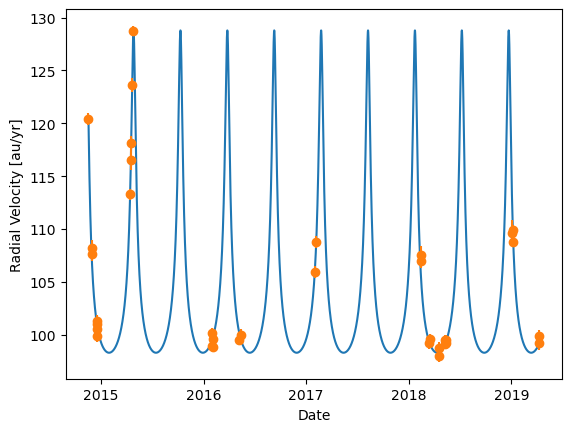

{'M0': np.float64(-2.0083766224115918),
 'K1': np.float64(15.237768726145319),
 'e': np.float64(0.6088941296702436),
 'P': np.float64(0.4572626319836945),
 'omega1': np.float64(0.04386874513969975),
 'systemic_velocity': np.float64(104.27431886836564),
 'M1': 0.81,
 'Tepoch': 2017.0}

In [5]:
orb = p.Orbit(**results.MAP_params)#, **{name: prior.value for name, prior in results.priors.items() if isinstance(prior, p.FixedPrior)})
date_full = np.linspace(date.min(), date.max(), 100000)
plt.plot(date_full, orb.rv(date_full, system=1), color='C0', label='MAP orbit')
plt.errorbar(date, epochs['BRV']*conv, yerr=epochs['e_BRV']*conv, fmt='o', color='C1', label='data')
plt.xlabel('Date')
plt.ylabel('Radial Velocity [au/yr]')
plt.show()
results.MAP_params

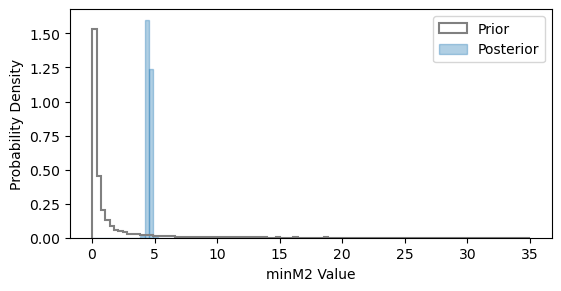

In [6]:
p.posterior_over_prior(results, params=['minM2']);

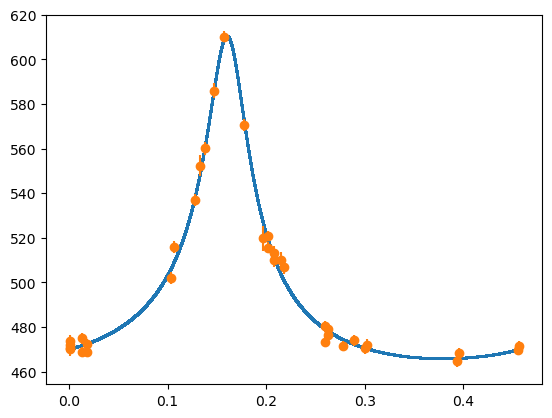

In [7]:
fit_P = results.MAP_params['P']
plt.errorbar(np.mod(date, fit_P), epochs['BRV'], yerr=epochs['e_BRV'], fmt='o', color='C1', label='data')
plt.scatter(np.mod(date_full, fit_P), orb.rv(date_full, system=1)/conv, color='C0', s=0.5, label='MAP orbit')
plt.show()

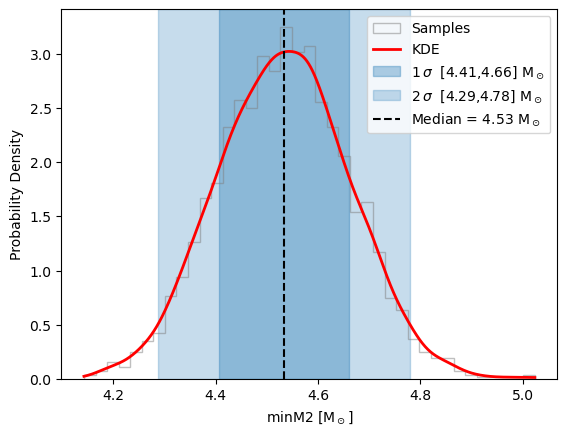

In [8]:
p.distribution(results, param='minM2', unit=r"M$_\odot$");

In [9]:
p.red_chi2(results, rv_data)

(np.float64(1.558717652192849),
 np.float64(1.553820642546693),
 np.float64(1.2484861441733541),
 np.float64(1.2465234223819033),
 27)

# ID 21859

     Type    ACS       RAdeg      DEdeg  Nobs
2378    m  21859  154.413468 -46.406906     8


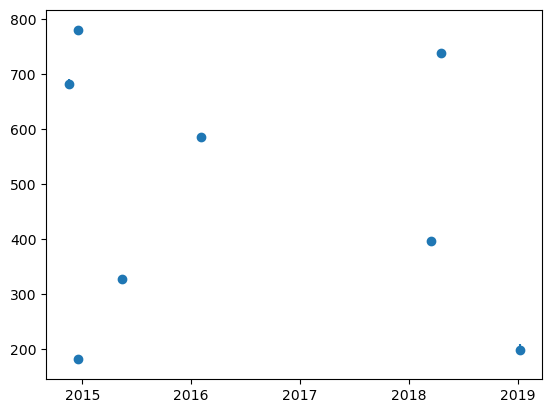

In [10]:
ID = 21859
M_vis = 0.61

list = Table.read("data/ngc3201/J_A+A_632_A3/list.dat", format="ascii.no_header").to_pandas()
colnames=["Type", "ACS", "RAdeg", "DEdeg", "Nobs"]
# Add column names to the DataFrame
list.columns = colnames
catalog = list[list['ACS'] == ID]

data = Table.read("data/ngc3201/J_A+A_632_A3/tablea1m.dat", format="ascii.no_header").to_pandas()
colnames=["ACS", "RAdeg", "DEdeg", "F606Wmag", "Date", "BRV", "e_BRV", "Pvar"]
data.columns = colnames
epochs = data[data['ACS'] == ID]

print(catalog)

date = np.array(2000.0 + (epochs['Date'] - 2451545.0)/365.25)
plt.errorbar(date, epochs['BRV'], yerr=epochs['e_BRV'], fmt='o')
plt.show()

In [11]:
import astropy.units as u
conv = (u.km/u.s).to(u.au/u.yr)

priors = {
    'Tepoch': p.FixedPrior(2017.0),
    'M1': p.FixedPrior(M_vis),
    'M0': p.UniformPrior(-np.pi, np.pi),
    'K1': p.UniformPrior(10.0*conv, 1000.0*conv),
    'P': p.LogUniformPrior(1e-4, 1e0),
    'e': p.UniformPrior(0.0, 0.9),
    'omega1': p.UniformPrior(0.0, 2*np.pi),
    'systemic_velocity': p.UniformPrior(300 * conv, 700 * conv),
}
rv_data = p.RadialVelocityData(
    t = date,
    rv = np.array(epochs['BRV'])*conv,
    rv_err = np.array(epochs['e_BRV'])*conv,
    system=1,
)
fitter = p.MCMCFitter(
    nwalkers=32,
    niter=10000,
    sample_params=['M0', 'K1', 'e', 'P', 'omega1', 'systemic_velocity'],
    **priors
)
results = fitter.fit(rv_data, np.random.default_rng(3201))

100%|██████████| 10000/10000 [00:07<00:00, 1271.14it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 200;
tau: [521.25645735 575.16204526 570.97582838 302.93984931 557.87198836
 566.46559581]


/Users/mw/Research/software/periapsis/src/periapsis/plotting/plots.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


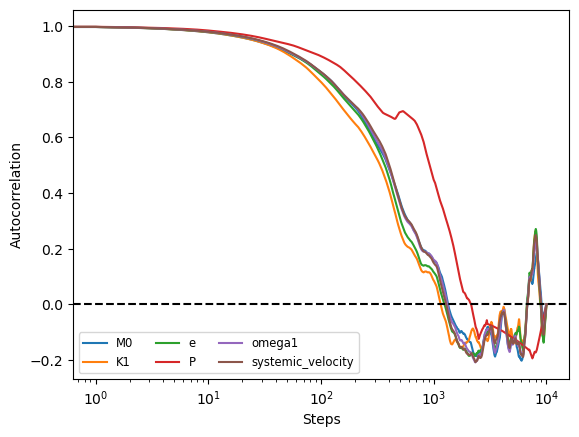

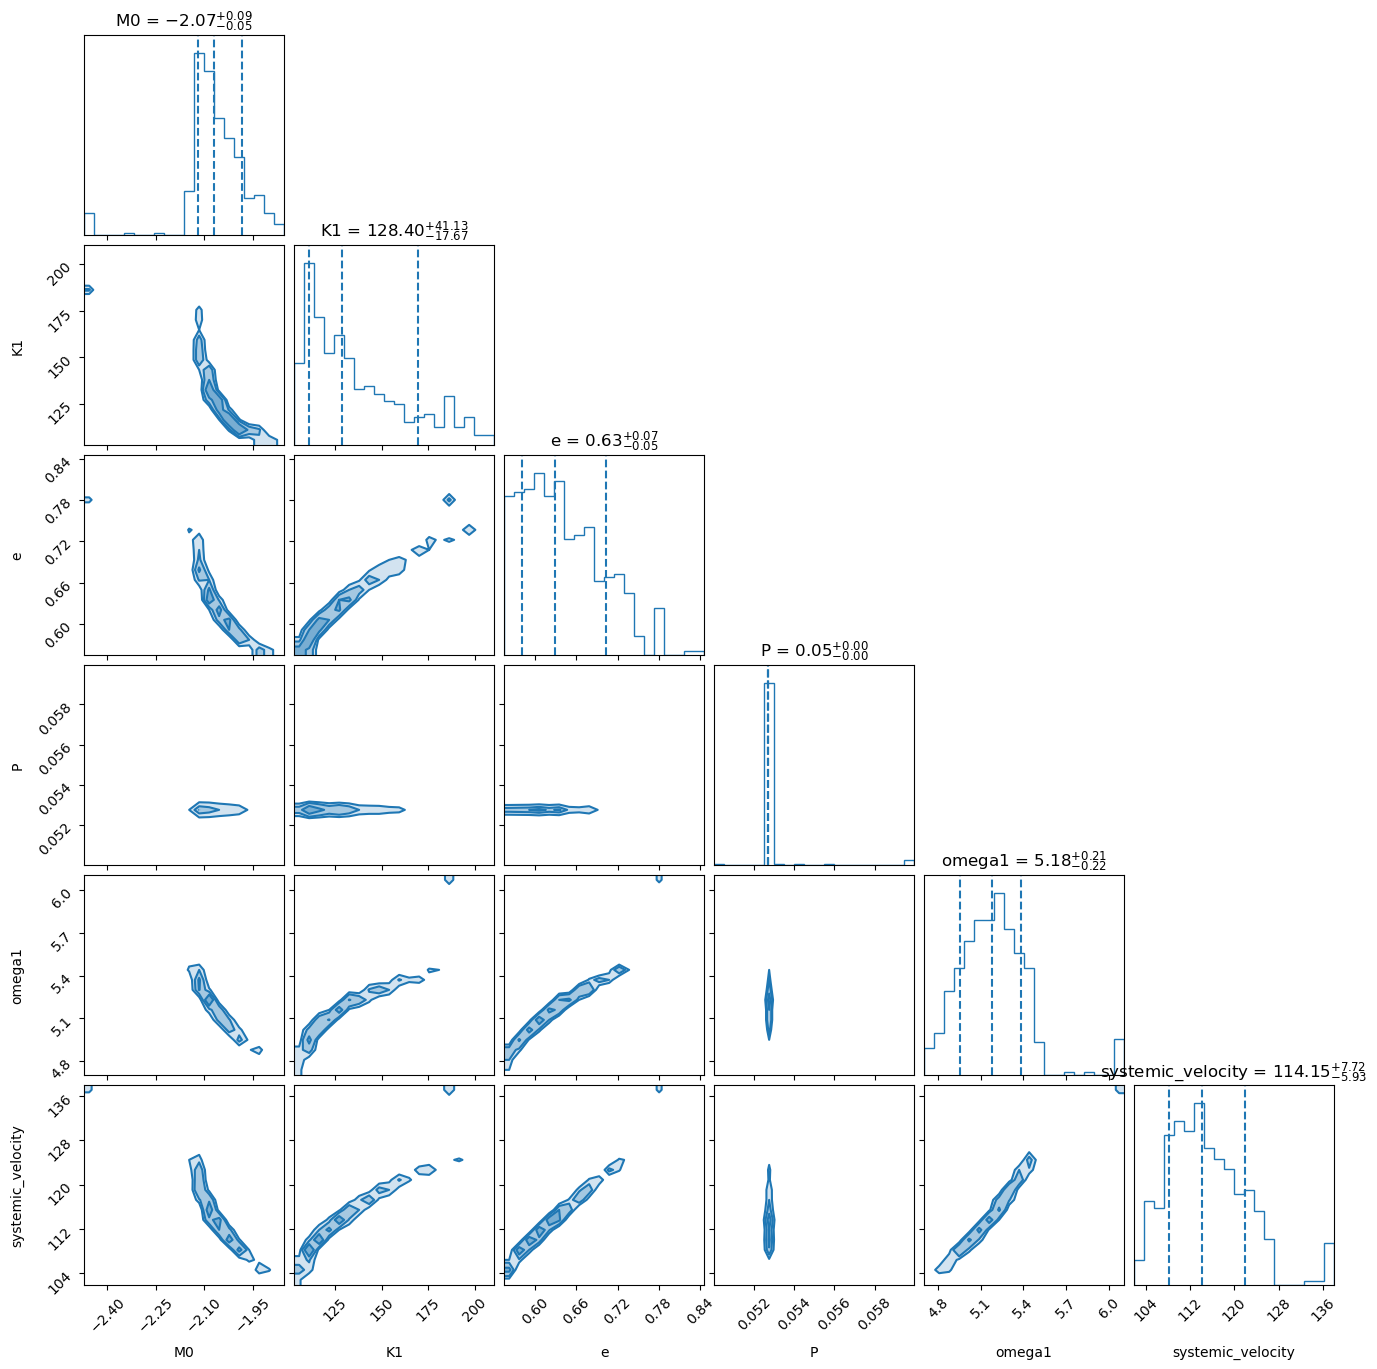

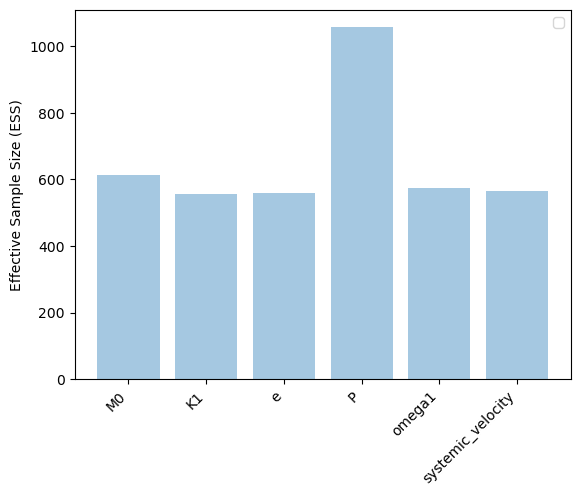

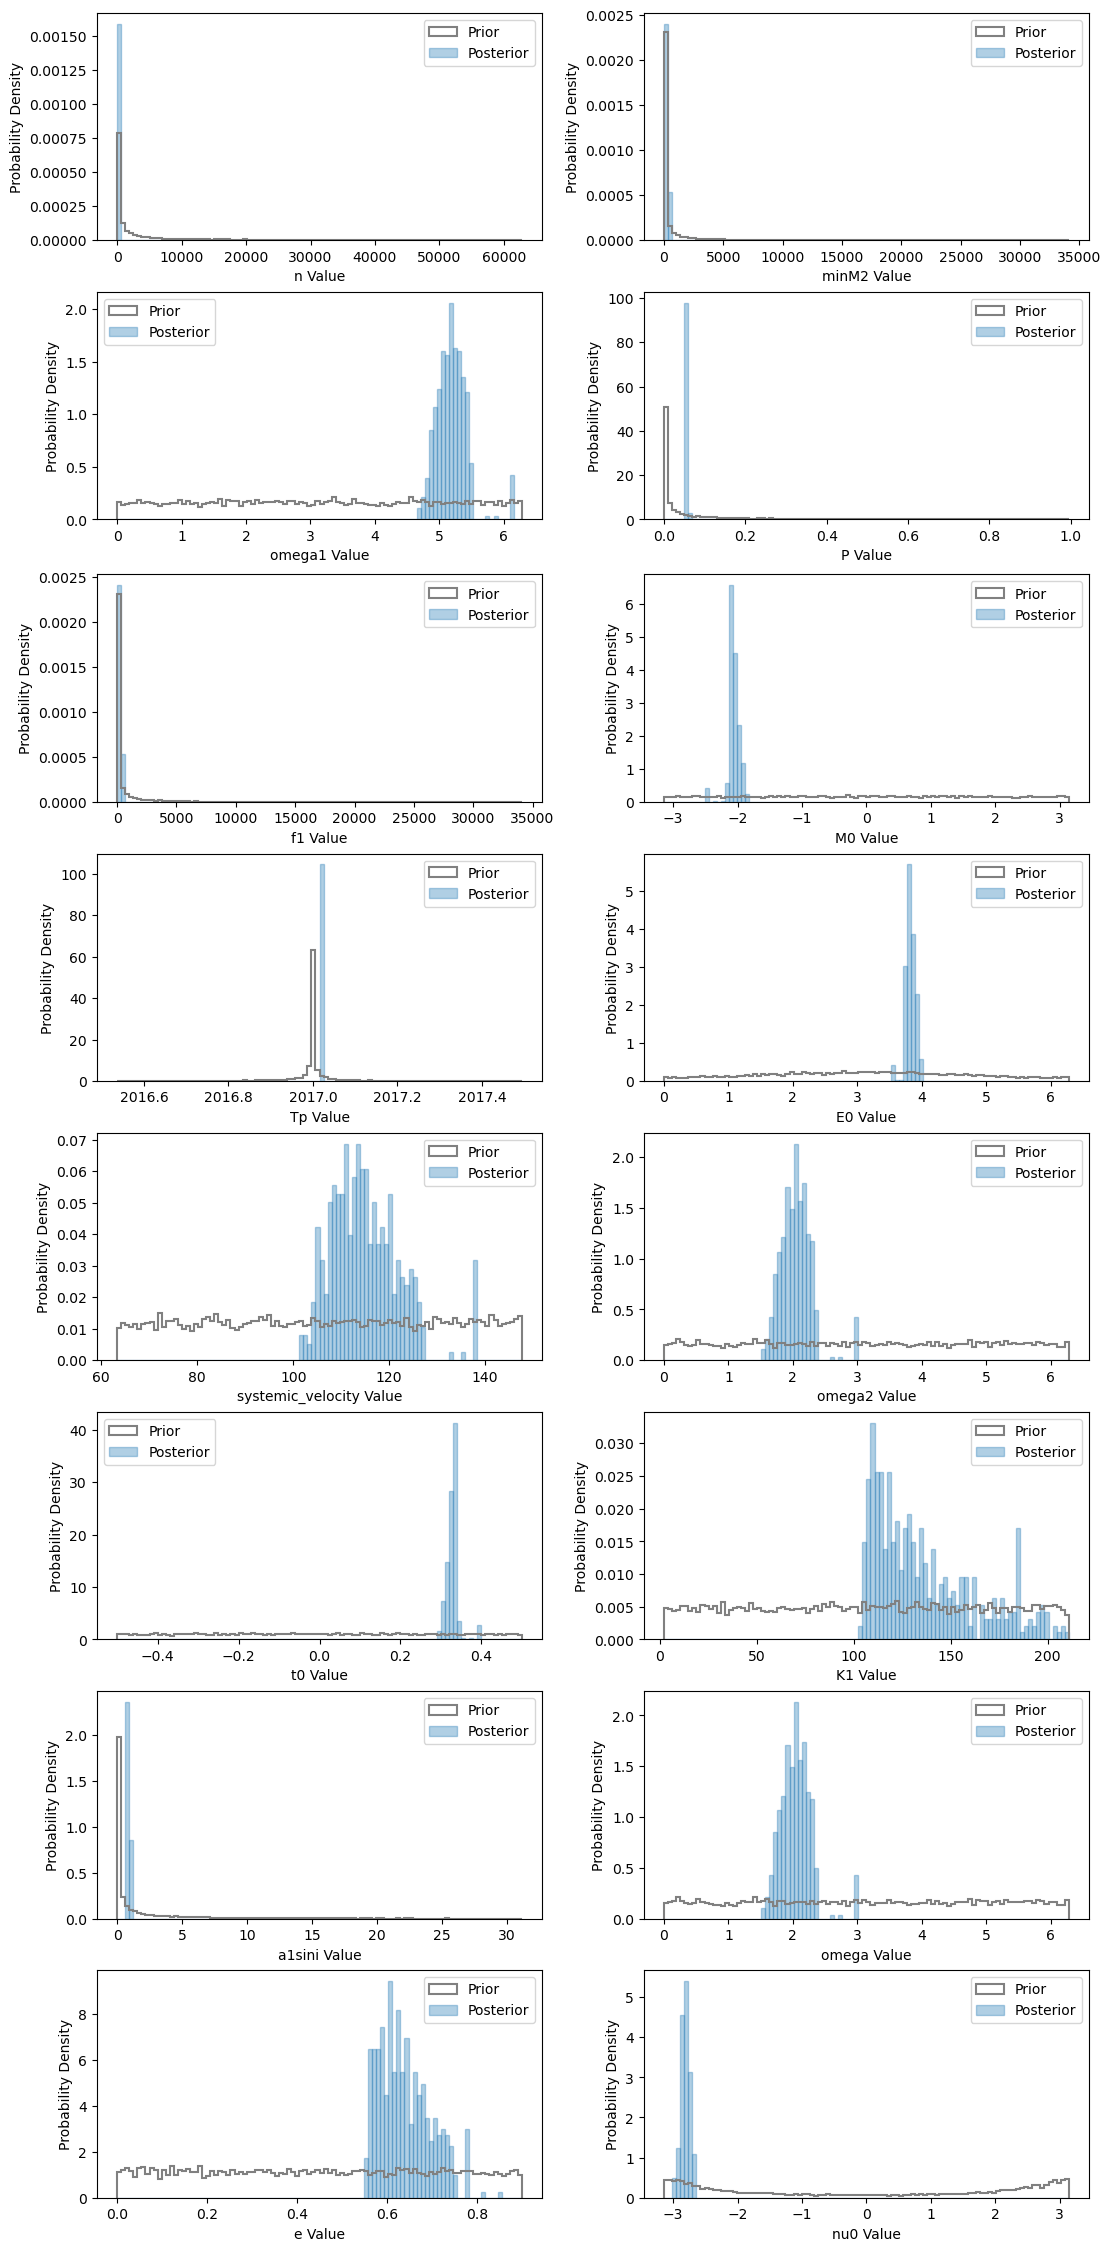

In [12]:
p.mcmc_autocorrelation_plot(results);
p.corner_plot(results);
p.ess_distribution_plot(results);
p.posterior_over_prior(results, params=results.covered_params-results.fixed_params);

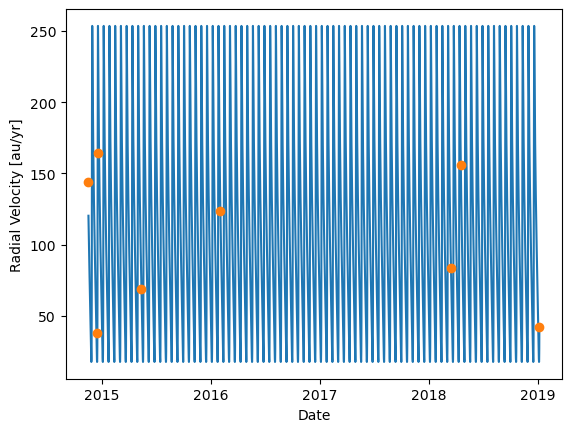

In [13]:
orb = p.Orbit(**results.MAP_params)#, **{name: prior.value for name, prior in results.priors.items() if isinstance(prior, p.FixedPrior)})
date_full = np.linspace(date.min(), date.max(), 100000)
plt.plot(date_full, orb.rv(date_full, system=1), color='C0', label='MAP orbit')
plt.errorbar(date, epochs['BRV']*conv, yerr=epochs['e_BRV']*conv, fmt='o', color='C1', label='data')
plt.xlabel('Date')
plt.ylabel('Radial Velocity [au/yr]')
plt.show()

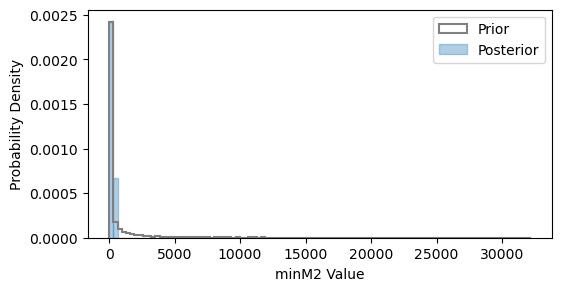

In [14]:
p.posterior_over_prior(results, params=['minM2']);

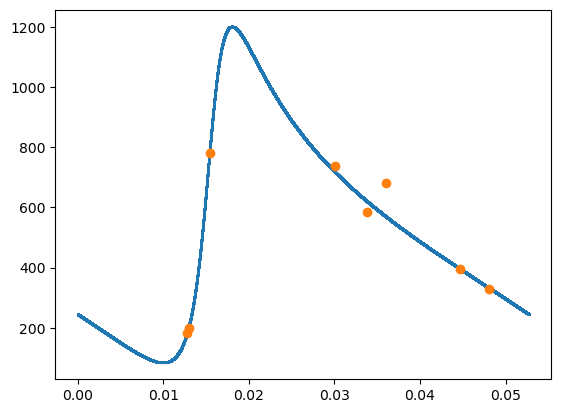

In [15]:
fit_P = results.MAP_params['P']
plt.errorbar(np.mod(date, fit_P), epochs['BRV'], yerr=epochs['e_BRV'], fmt='o', color='C1', label='data')
plt.scatter(np.mod(date_full, fit_P), orb.rv(date_full, system=1)/conv, color='C0', s=0.5, label='MAP orbit')
plt.show()

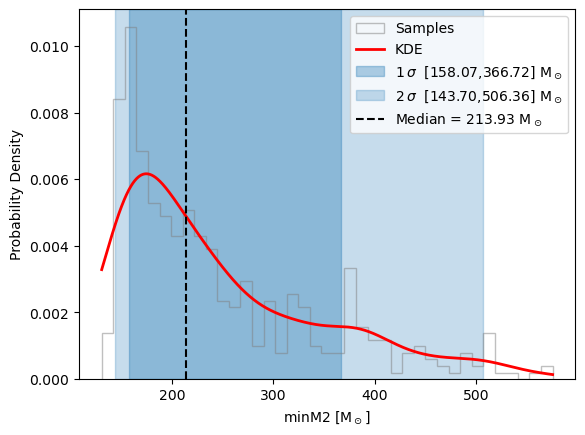

In [16]:
p.distribution(results, param='minM2', unit=r"M$_\odot$");

# ID 5132

    Type   ACS       RAdeg      DEdeg  Nobs
122    m  5132  154.400344 -46.425849    22


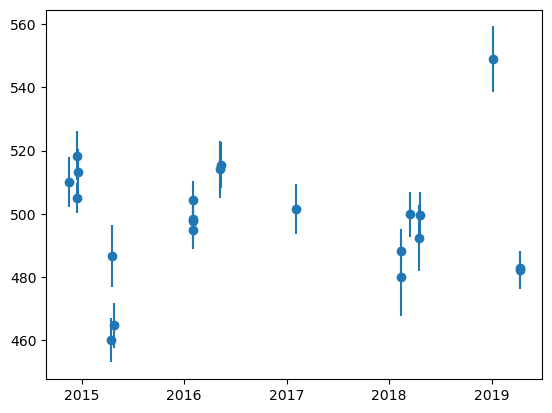

In [17]:
ID = 5132
M_vis = 0.64

list = Table.read("data/ngc3201/J_A+A_632_A3/list.dat", format="ascii.no_header").to_pandas()
colnames=["Type", "ACS", "RAdeg", "DEdeg", "Nobs"]
# Add column names to the DataFrame
list.columns = colnames
catalog = list[list['ACS'] == ID]

data = Table.read("data/ngc3201/J_A+A_632_A3/tablea1m.dat", format="ascii.no_header").to_pandas()
colnames=["ACS", "RAdeg", "DEdeg", "F606Wmag", "Date", "BRV", "e_BRV", "Pvar"]
data.columns = colnames
epochs = data[data['ACS'] == ID]

print(catalog)

date = np.array(2000.0 + (epochs['Date'] - 2451545.0)/365.25)
plt.errorbar(date, epochs['BRV'], yerr=epochs['e_BRV'], fmt='o')
plt.show()

In [18]:
import astropy.units as u
conv = (u.km/u.s).to(u.au/u.yr)

priors = {
    'Tepoch': p.FixedPrior(2017.0),
    'M1': p.FixedPrior(M_vis),
    'M0': p.UniformPrior(-np.pi, np.pi),
    'K1': p.UniformPrior(10.0*conv, 1000.0*conv),
    'P': p.LogUniformPrior(1e-4, 1e0),
    'e': p.UniformPrior(0.0, 0.9),
    'omega1': p.UniformPrior(0.0, 2*np.pi),
    'systemic_velocity': p.UniformPrior(300 * conv, 700 * conv),
}
rv_data = p.RadialVelocityData(
    t = date,
    rv = np.array(epochs['BRV'])*conv,
    rv_err = np.array(epochs['e_BRV'])*conv,
    system=1,
)
fitter = p.MCMCFitter(
    nwalkers=32,
    niter=10000,
    sample_params=['M0', 'K1', 'e', 'P', 'omega1', 'systemic_velocity'],
    **priors
)
results = fitter.fit(rv_data, np.random.default_rng(3201))

100%|██████████| 10000/10000 [00:07<00:00, 1412.26it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 200;
tau: [198.05860132 623.01374875 577.1783715  200.2619188  177.07575373
 566.58961933]


/Users/mw/Research/software/periapsis/src/periapsis/plotting/plots.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


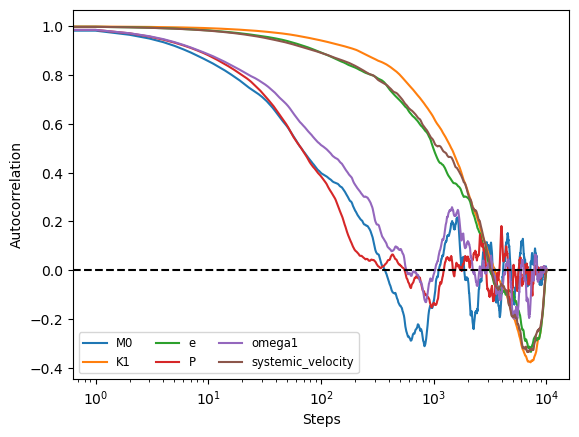

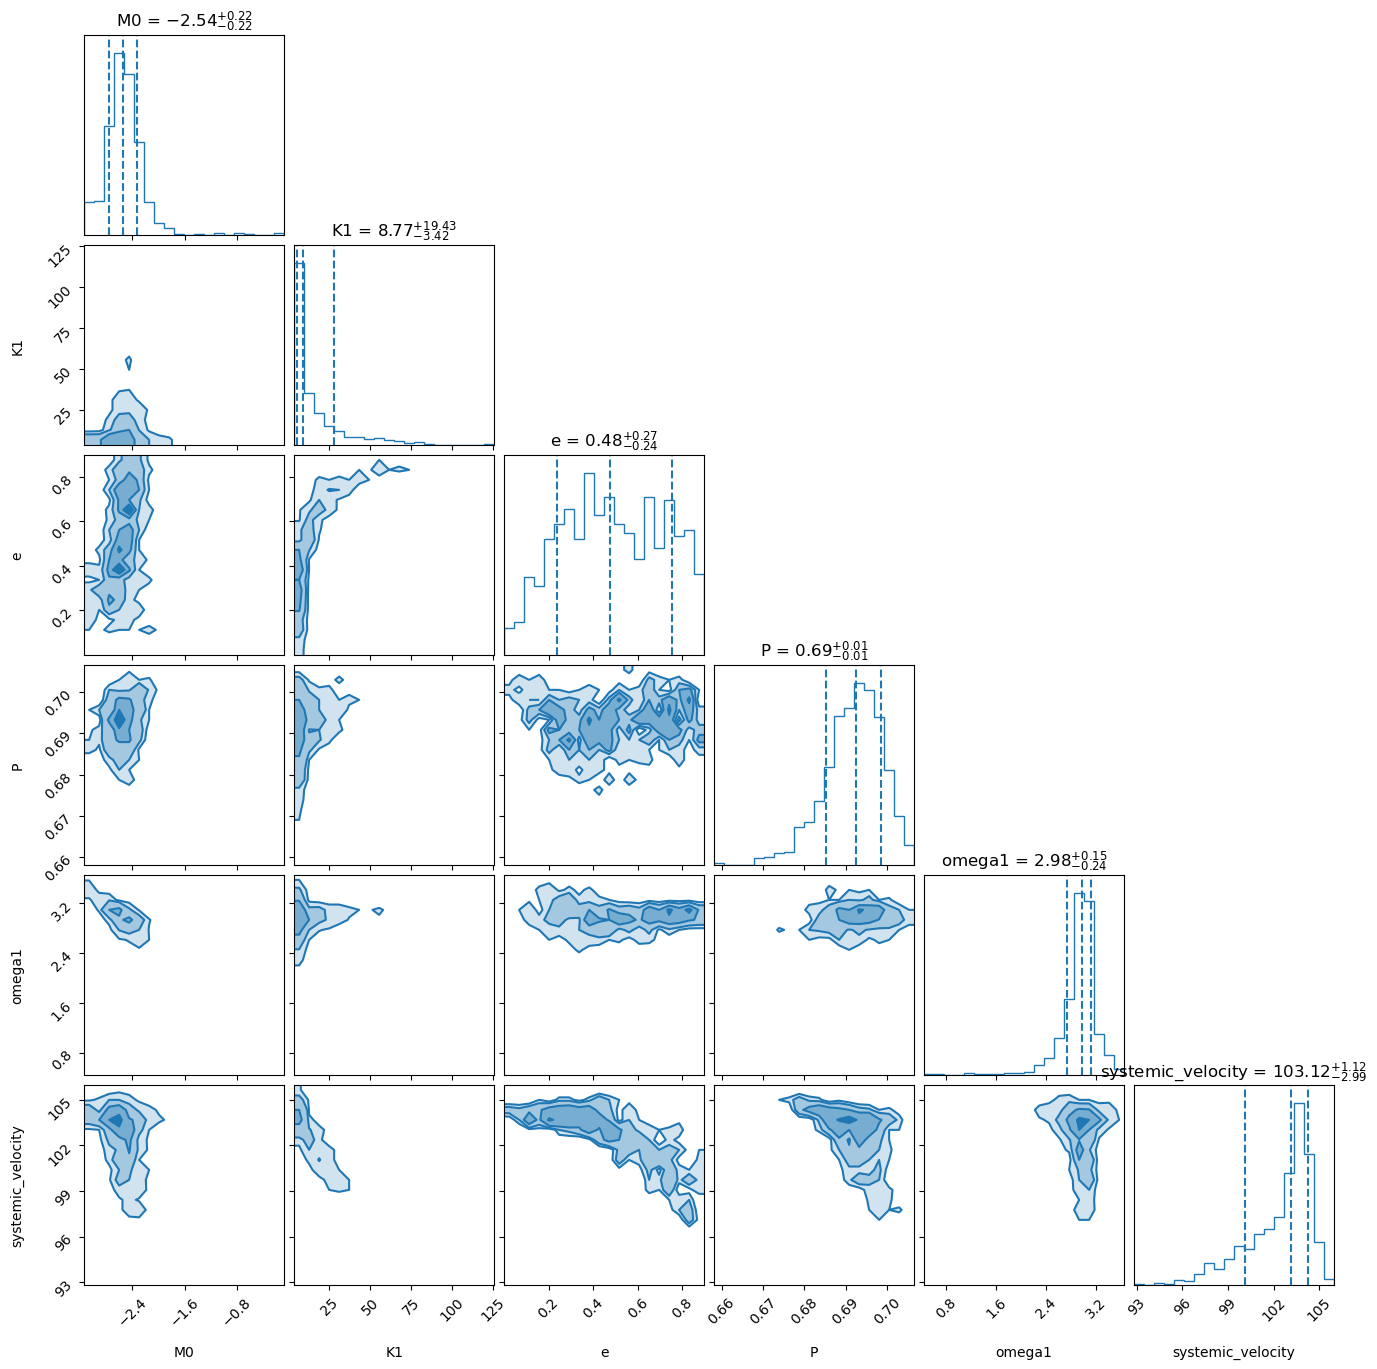

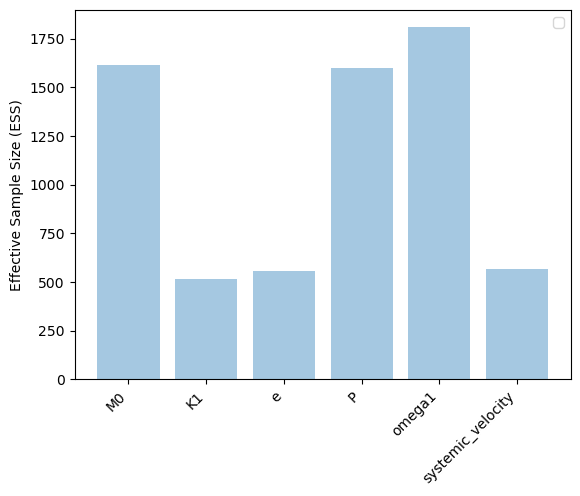

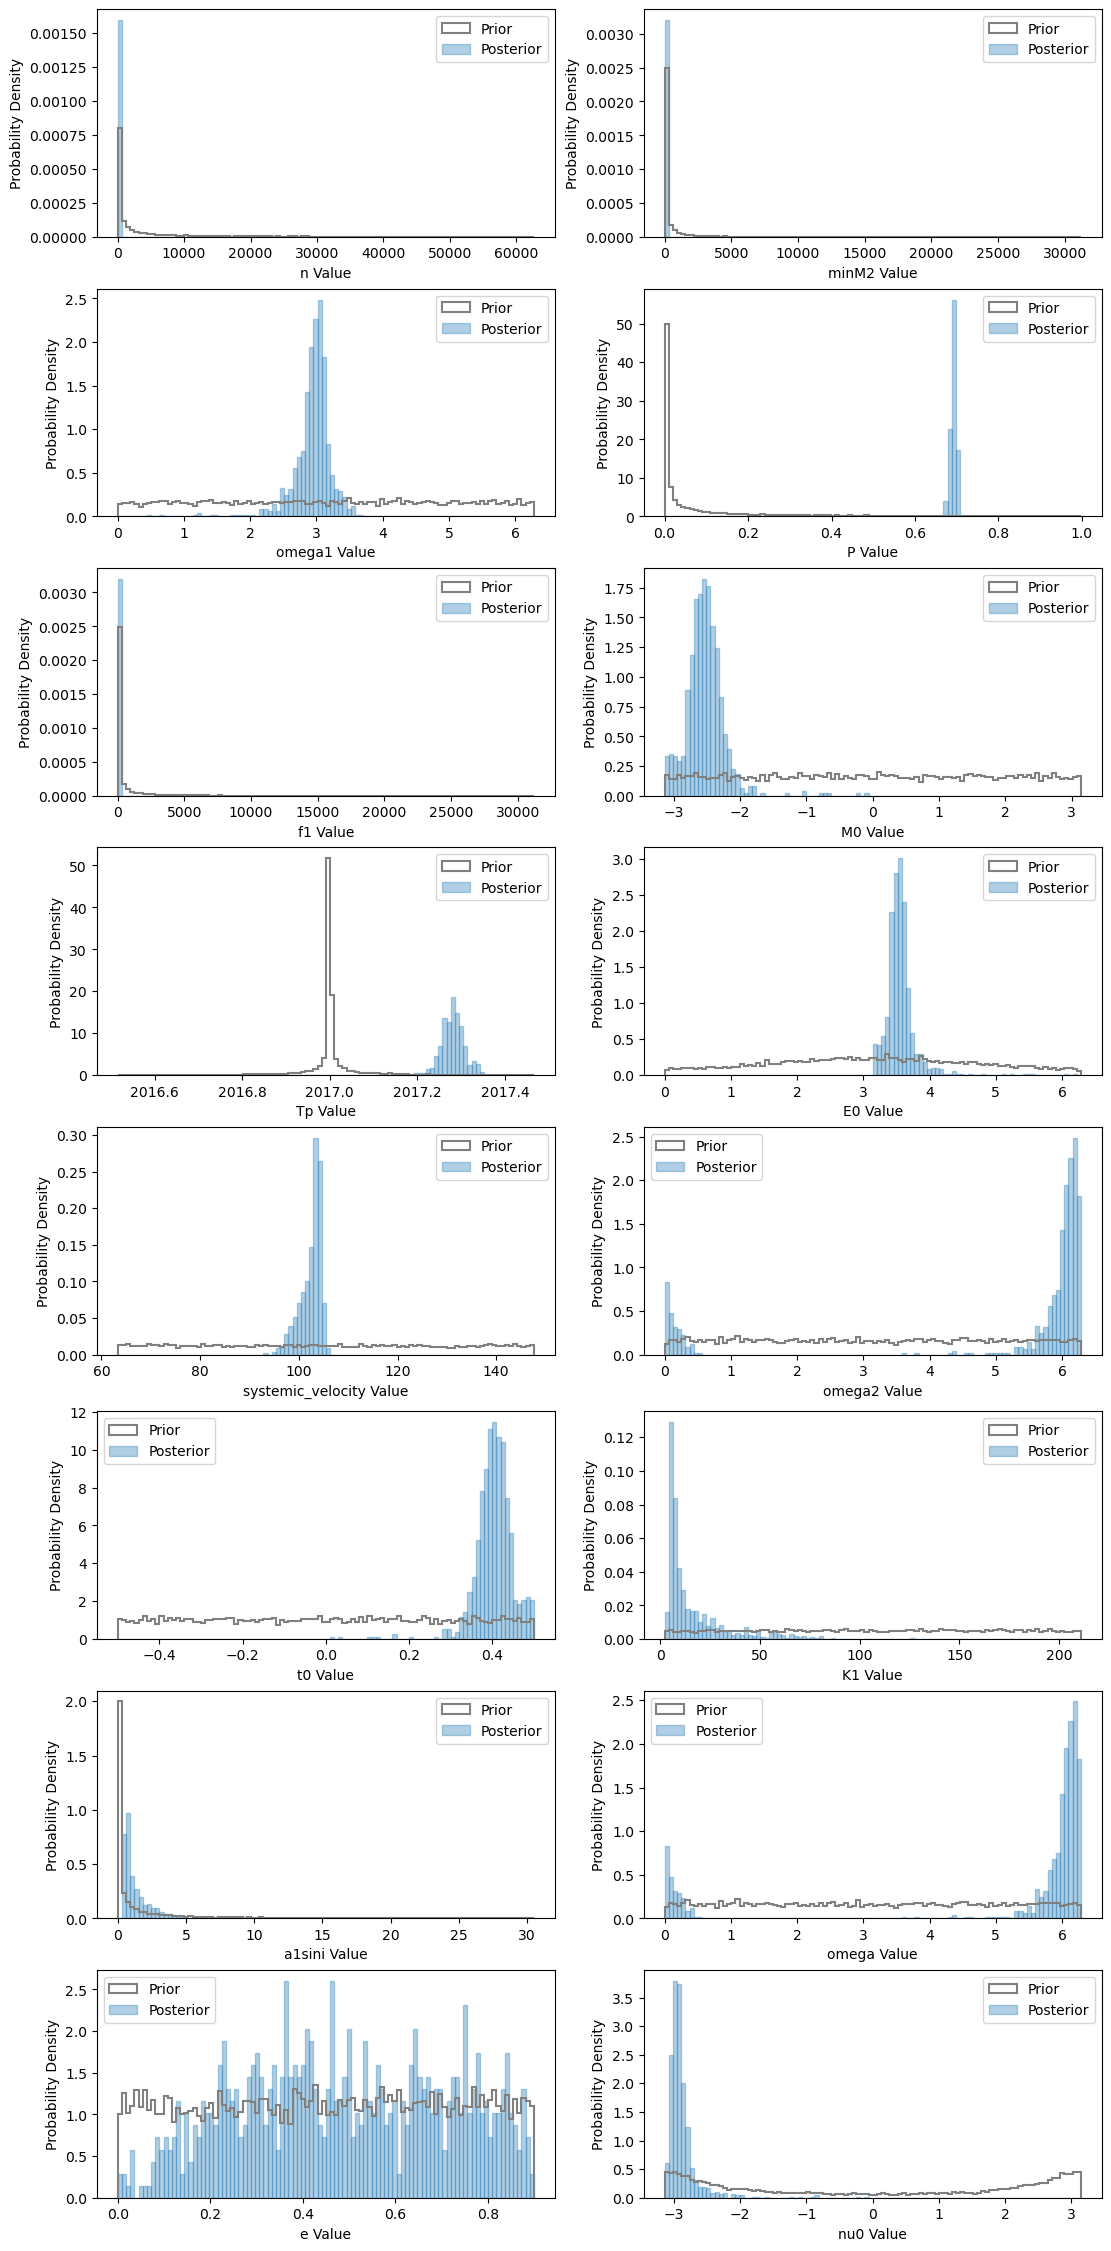

In [19]:
p.mcmc_autocorrelation_plot(results);
p.corner_plot(results);
p.ess_distribution_plot(results);
p.posterior_over_prior(results, params=results.covered_params-results.fixed_params);

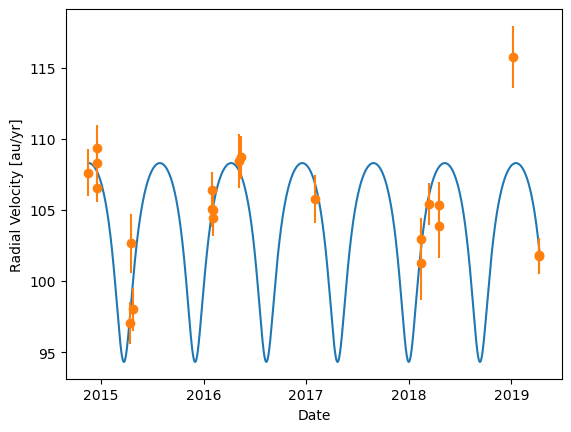

In [20]:
orb = p.Orbit(**results.MAP_params)#, **{name: prior.value for name, prior in results.priors.items() if isinstance(prior, p.FixedPrior)})
date_full = np.linspace(date.min(), date.max(), 100000)
plt.plot(date_full, orb.rv(date_full, system=1), color='C0', label='MAP orbit')
plt.errorbar(date, epochs['BRV']*conv, yerr=epochs['e_BRV']*conv, fmt='o', color='C1', label='data')
plt.xlabel('Date')
plt.ylabel('Radial Velocity [au/yr]')
plt.show()

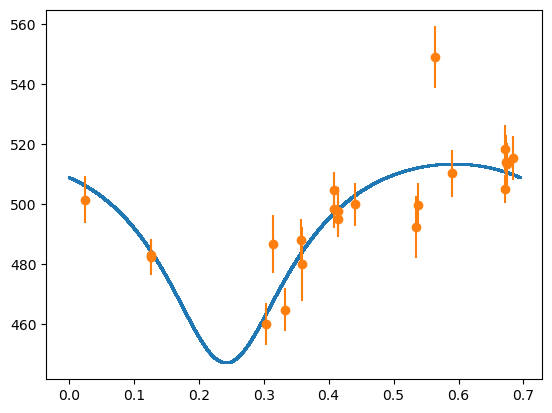

In [21]:
fit_P = results.MAP_params['P']
plt.errorbar(np.mod(date, fit_P), epochs['BRV'], yerr=epochs['e_BRV'], fmt='o', color='C1', label='data')
plt.scatter(np.mod(date_full, fit_P), orb.rv(date_full, system=1)/conv, color='C0', s=0.5, label='MAP orbit')
plt.show()

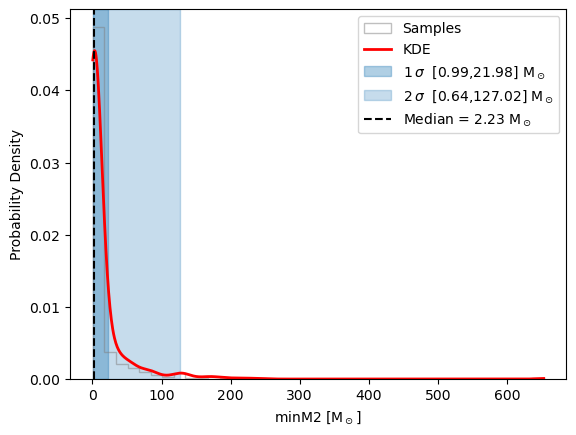

In [22]:
p.distribution(results, param='minM2', unit=r"M$_\odot$");

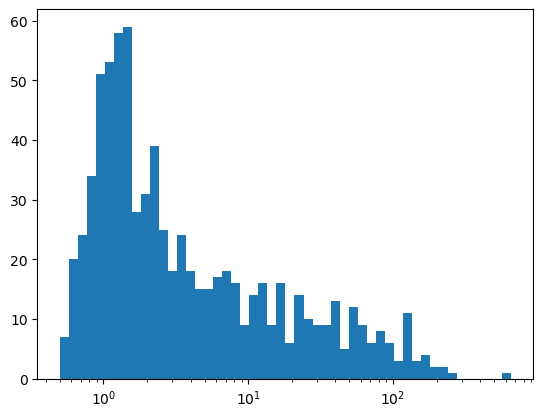

In [23]:
plt.hist(results["minM2"], bins=np.geomspace(results["minM2"].min(), results["minM2"].max(), 51))
plt.xscale('log')
plt.show()